<a href="https://colab.research.google.com/github/gautami06647/AI-ML-internship-assignments/blob/main/Linear_Regression_projecyt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Error: 'data.csv' not found. Please ensure the file is in the same folder.


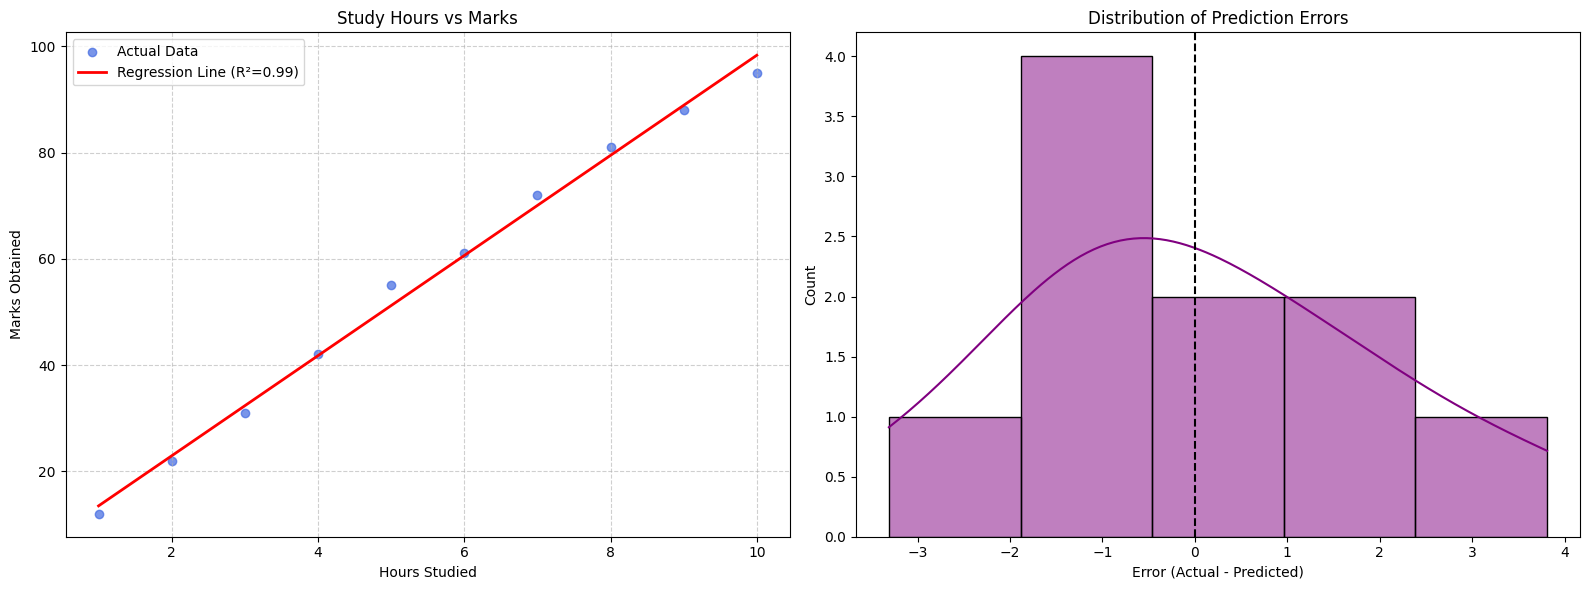

Model Equation: Marks = (9.42 * Hours) + 4.07
Overall Accuracy: 99.49%

--- Final Dataset Table (Last 5 Rows) ---
   Hours  Marks  Predicted  Difference
5      6     61      60.61        0.39
6      7     72      70.04        1.96
7      8     81      79.46        1.54
8      9     88      88.88       -0.88
9     10     95      98.31       -3.31

Prediction Test: A student studying 7.5 hours is predicted to score 74.75


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# 1. LOAD DATA
# Ensure your data.csv has headers: Hours, Marks
try:
    df = pd.read_csv('data.csv')
    print("Dataset Loaded Successfully!")
except FileNotFoundError:
    print("Error: 'data.csv' not found. Please ensure the file is in the same folder.")
    # Fallback: Generating sample data so the code doesn't crash
    data = {'Hours': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
            'Marks': [12, 22, 31, 42, 55, 61, 72, 81, 88, 95]}
    df = pd.DataFrame(data)

# 2. DEFINE X AND Y
# Reshape X to 2D array as required by Scikit-Learn
X = df[['Hours']].values
y_actual = df['Marks'].values

# 3. TRAIN THE MODEL
model = LinearRegression()
model.fit(X, y_actual)

# 4. PREDICT & CALCULATE ERRORS
y_pred = model.predict(X)
df['Predicted'] = np.round(y_pred, 2)
df['Difference'] = np.round(y_actual - y_pred, 2)

# 5. CALCULATE ACCURACY (R2 Score)
accuracy = r2_score(y_actual, y_pred)

# --- VISUALIZATION ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Regression Line
axes[0].scatter(X, y_actual, color='royalblue', alpha=0.7, label='Actual Data')
axes[0].plot(X, y_pred, color='red', linewidth=2, label=f'Regression Line (R²={accuracy:.2f})')
axes[0].set_title('Study Hours vs Marks')
axes[0].set_xlabel('Hours Studied')
axes[0].set_ylabel('Marks Obtained')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.6)

# Plot 2: Error Distribution (Residuals)
sns.histplot(df['Difference'], kde=True, ax=axes[1], color='purple')
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set_title('Distribution of Prediction Errors')
axes[1].set_xlabel('Error (Actual - Predicted)')

plt.tight_layout()
plt.show()

# 6. PRINT FINAL RESULTS
print(f"Model Equation: Marks = ({model.coef_[0]:.2f} * Hours) + {model.intercept_:.2f}")
print(f"Overall Accuracy: {accuracy:.2%}")
print("\n--- Final Dataset Table (Last 5 Rows) ---")
print(df.tail())

# 7. QUICK PREDICTION TEST
test_val = 7.5
pred_val = model.predict([[test_val]])
print(f"\nPrediction Test: A student studying {test_val} hours is predicted to score {pred_val[0]:.2f}")